In [1]:
### Data exploration by timo ###

In [7]:
## 1. imports


# for specifying paths
import os

# basic functionality
import random
import numpy as np
import pandas as pd

# libraries for plotting
import seaborn as sns
import matplotlib.pyplot as plt


In [12]:
## 2. upload data to jupyter such that it is accessible

# check working directory
os.getcwd()
# --> kernel runs on a remote Linux machine, hence need to upload data to linux jupyter environment

# to do NOW: upload files manually on jupyter

# check if upload worked
os.listdir()

['.ipynb_checkpoints', 'exploration_t.ipynb', 'mega_val.csv', 'mega_train.csv']

In [14]:
## 3. read in data

# read in and store
train_seq_data = pd.read_csv("mega_train.csv")
#val_seq_data = pd.read_csv("mega_val.csv") #uncomment if needed

In [24]:
## 4. explore data

In [35]:
# 4.1 dimensions and structure

# columns
train_seq_data.info()

# glimpse 
train_seq_data.head() # wt sequences
train_seq_data.tail() # mut sequences

<class 'pandas.DataFrame'>
RangeIndex: 216919 entries, 0 to 216918
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  216919 non-null  int64  
 1   name        216919 non-null  str    
 2   ddG_ML      216919 non-null  float64
 3   mut_type    216919 non-null  str    
 4   WT_name     216919 non-null  str    
 5   aa_seq      216919 non-null  str    
 6   wt_seq      216919 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 39.9 MB


,Unnamed: 0,name,ddG_ML,mut_type,WT_name,aa_seq,wt_seq
216914,216914,HEEH_rd3_0055.pdb_L43W,0.143385,L43W,HEEH_rd3_0055.pdb,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQW,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQL
216915,216915,HEEH_rd3_0055.pdb_L43Y,0.059886,L43Y,HEEH_rd3_0055.pdb,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQY,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQL
216916,216916,HEEH_rd3_0055.pdb_L43F,0.009488,L43F,HEEH_rd3_0055.pdb,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQF,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQL
216917,216917,HEEH_rd3_0055.pdb_L43P,-0.539100,L43P,HEEH_rd3_0055.pdb,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQP,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQL
216918,216918,HEEH_rd3_0055.pdb_L43C,0.071329,L43C,HEEH_rd3_0055.pdb,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQC,TIEDAIKKLLKLAQKGQPYTFGDFTVTSEEEAKKLAKWLKKQL


In [52]:
## 4.2 predictor variable (sequences)

# check by how many AA mut sequences differ from wt sequences (i.e. verify whether all datapoints are point mutations)

for idx, row in train_seq_data.iterrows():
    n_diff = sum (a!=b for a,b in zip(row['aa_seq'], row['wt_seq']))
    if n_diff != 1:
        print(f'warning: row {idx} has {n_diff} differences')

count    216919.000000
mean         -0.739309
std           1.001078
min          -5.662802
25%          -1.251454
50%          -0.491161
75%          -0.035559
max           3.099443
Name: ddG_ML, dtype: float64


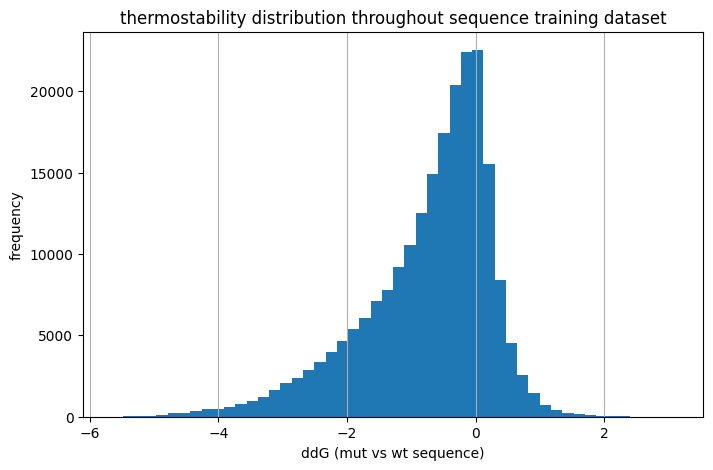

In [42]:
# outcome variable (ddG)

# check distribution
print(train_seq_data["ddG_ML"].describe())

plt.figure(figsize=(8,5))
plt.hist(train_seq_data["ddG_ML"], bins=50)
plt.title("thermostability distribution throughout sequence training dataset")
plt.xlabel("ddG (mut vs wt sequence)")
plt.ylabel("frequency")
plt.grid(axis='x')
plt.show()